# ⚖️ Karşılaştırma — İki Veri Setinde Süt Verimi Tahmini

**Amaç:** Aynı verim tahmini yaklaşımını iki farklı ülkenin veri setinde deneyip
sonuçları karşılaştırmak. Böylece "başarının veriye mi, modele mi bağlı olduğunu"
görmek.

**Veri setleri:**
- **Rwanda (91 inek):** Yem miktarı, ağırlık gibi ADİL özellikler içeriyor.
- **Mendeley / Çek (723 inek):** Yem verisi YOK; sadece ırk, parity, mevsim var.

**Beklenti:** Yem verisi içeren Rwanda setinin daha yüksek R² vermesi — çünkü
verimi belirleyen asıl bilgi (yem) orada mevcut.

In [3]:
from google.colab import files
print("İki dosyayı da seçin: Rwanda ve Mendeley Excel dosyaları")
yuklenen = files.upload()

print("\nYüklenen dosyalar:")
for ad in yuklenen.keys():
    print("-", ad)

İki dosyayı da seçin: Rwanda ve Mendeley Excel dosyaları


Saving Dataset_cow_performance.xlsx to Dataset_cow_performance (1).xlsx
Saving Specific data recorded on individual cows under lactation in Rwanda 2020-2021.xlsx to Specific data recorded on individual cows under lactation in Rwanda 2020-2021 (1).xlsx

Yüklenen dosyalar:
- Dataset_cow_performance (1).xlsx
- Specific data recorded on individual cows under lactation in Rwanda 2020-2021 (1).xlsx


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Otomatik dosya bulma (isimde "Rwanda" ve "cow_performance" geçenler)
rwanda_dosya = [a for a in yuklenen.keys() if "Rwanda" in a][0]
mendeley_dosya = [a for a in yuklenen.keys() if "cow_performance" in a][0]

sonuclar = {}

# ---- RWANDA (yem verili) ----
dfr = pd.read_excel(rwanda_dosya, sheet_name="Raw data", header=10)
adil_r = ["cowbreed", "cowageinyears", "parity", "Bodyweight", "DMIR kg",
          "DM served", "leftover", "daysinmilk", "lactationperiod",
          "DMfeeds", "NDF feeds", "waterday", "Total milk performance"]
dfr = dfr[adil_r].dropna()
# Convert 'cowageinyears' to numeric, coercing errors to NaN
dfr['cowageinyears'] = pd.to_numeric(dfr['cowageinyears'], errors='coerce')
dfr = dfr.dropna(subset=['cowageinyears']) # Drop rows where conversion failed
dfr = pd.get_dummies(dfr, columns=["cowbreed", "lactationperiod"], drop_first=True)
Xr = dfr.drop("Total milk performance", axis=1)
yr = dfr["Total milk performance"]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)
mr = LinearRegression().fit(Xr_tr, yr_tr)
pr = mr.predict(Xr_te)
sonuclar["Rwanda (yem VAR)"] = r2_score(yr_te, pr)

# ---- MENDELEY (yem yok) ----
dfm = pd.read_excel(mendeley_dosya, sheet_name="Dataset")
at_m = ["ID", "ID Cow", "ID cow with Codex", "Calving Date", "ID Breed",
        "Farm ID", "Stable ID", "Method of Performance Control Database",
        "GZW/SIH", "F (kg)", "P (kg)", "L (kg)", "F (%)", "P (%)", "L (%)"]
dfm = dfm.drop(columns=at_m)
en_sik = dfm["Breed"].value_counts().nlargest(4).index
dfm["Breed_grup"] = dfm["Breed"].apply(lambda x: x if x in en_sik else "Diger")
dfm = dfm.drop(columns=["Breed"])
dfm = pd.get_dummies(dfm, columns=["Breed_grup", "Calving Season"], drop_first=True)
Xm = dfm.drop("MY (kg)", axis=1)
ym = dfm["MY (kg)"]
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.2, random_state=42)
mm = LinearRegression().fit(Xm_tr, ym_tr)
pm = mm.predict(Xm_te)
sonuclar["Mendeley (yem YOK)"] = r2_score(ym_te, pm)

print("--- KARŞILAŞTIRMA (R²) ---")
for k, v in sonuclar.items():
    print(f"{k:22} → R²: {round(v, 3)}")

--- KARŞILAŞTIRMA (R²) ---
Rwanda (yem VAR)       → R²: 0.802
Mendeley (yem YOK)     → R²: 0.097




Rwanda (yem VAR) → R²: 0.802
Mendeley (yem YOK) → R²: 0.097

İki farklı ülkenin verisi, aynı model, ama sonuçlar gece-gündüz. Ve bu fark tesadüf değil — sebebi net: Rwanda'da yem verisi var, Mendeley'de yok

verim tahmininin başarısı modelde değil, verinin doğru özellikleri içermesinde!!!!

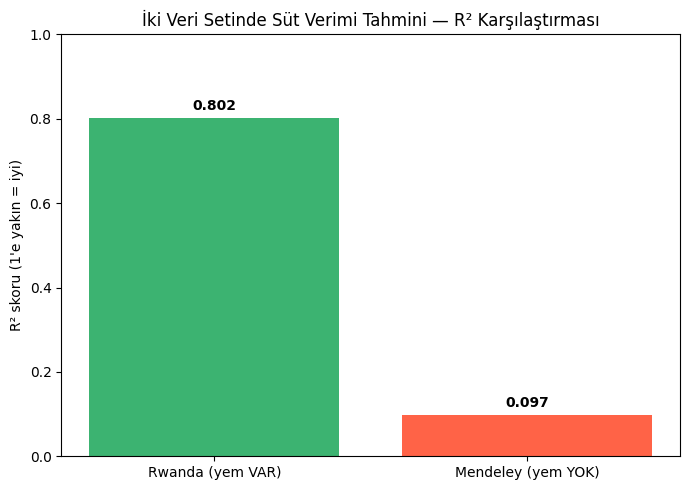

In [6]:
import matplotlib.pyplot as plt

isimler = list(sonuclar.keys())
degerler = list(sonuclar.values())
renkler = ["mediumseagreen", "tomato"]

plt.figure(figsize=(7, 5))
plt.bar(isimler, degerler, color=renkler)
plt.title("İki Veri Setinde Süt Verimi Tahmini — R² Karşılaştırması")
plt.ylabel("R² skoru (1'e yakın = iyi)")
plt.ylim(0, 1)
for i, v in enumerate(degerler):
    plt.text(i, v + 0.02, str(round(v, 3)), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

KAPANIŞŞŞ :))

Bu notebook dosyasının amacı görselleşirmek son bi vurgulama yapıp noktayı koymaktır.

Gördüğünüz gibi yem verisi olmayan mendeley(çek) modelinde 0.097 gibi cok kötü bi sonuç çıkmış.Ancak bir sonraki eğitim çalışmamızda;yağ, protein gibi sütunları cıkarmamıştık.Ancak bu seferde modelimiz,eğitilmeden bu verileri kullanarak bize cevap vermiş oldu.kendini eğitmedi(Aslında buna kopya çekti- ya da terimsel karşılığı olarak `data leaakage`  yaşamış olduk bu da bizim projemiz için  ve de model eğitmede hiç istemeyeceğimiz şeyler ).


Bizde sonraki colab dosyamızda bambaşka bir veri seti bulduk bu sefer kopya çekmedi çünkü tüm özellikler süt sağolmadan önce bilinen özelliklerdi 91 satırlık bir veri setimizdi.Burda MAE  ve r2 yi hesapladık ve gerçekten eğitilmiş bir model elde etmiş olduk hatta regresyonumuz random forest ımızı geçti bu da sürekli farklı bi deneyim akzandırmış oldu bana her  zaman aynı şeyler yaşanacak diye bi şey yok demek oluyo bu da.



KISACASI BU NOTEBOOK TÜM BUNLARIN KARŞILAŞTIRILMASI VE GENEL ÖZETİ ŞEKLİNDE OLMUŞ OLDU.



VE PROJE ADINA İLK KAYDEDECEĞİMİZ MODELİMİZ OLMUŞ OLDU (GERÇEKTEN ÖĞRENEN,SIZINTI OLMAYAN ,KOPYA ÇEKMEYEN)..joblib ile .pkl olarak kaydetnmeye değer ilerleyen zamanlarda kullanıcaz zaten bunu :)))))))))
